In [1]:
# read data
import pandas as pd

df = pd.read_csv("seeds_dataset.txt", sep="\t+", header=None)
# 1 area A,
# 2 perimeter P,
# 3 compactness C = 4*pi*A/P^2,
# 4 length of kernel,
# 5 width of kernel,
# 6 asymmetry coefficient
# 7 length of kernel groove.
# 8 target
df.columns = [
    "area",
    "perimeter",
    "compactness",
    "length_kernel",
    "width_kernel",
    "asymmetry_coefficient",
    "length_kernel_groove",
    "target",
]

C:\Users\esqui\AppData\Local\Temp\ipykernel_22404\2454853134.py:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv("seeds_dataset.txt", sep="\t+", header=None)


In [2]:
# show basic statistics
df.describe()

,area,perimeter,compactness,length_kernel,width_kernel,asymmetry_coefficient,length_kernel_groove,target
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


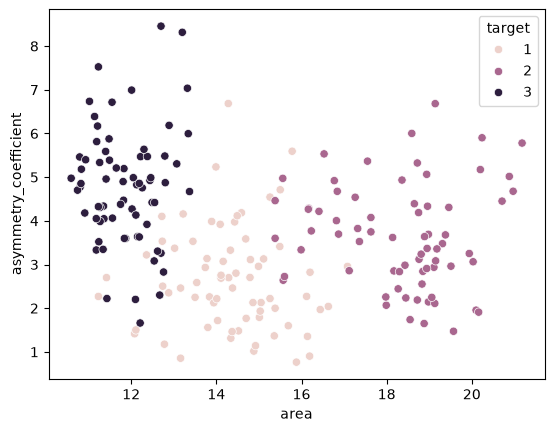

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# visualize area vs asymmetry_coefficient
sns.scatterplot(
    x="area",
    y="asymmetry_coefficient",
    data=df,
    hue="target",
    legend="full",
)
plt.show()

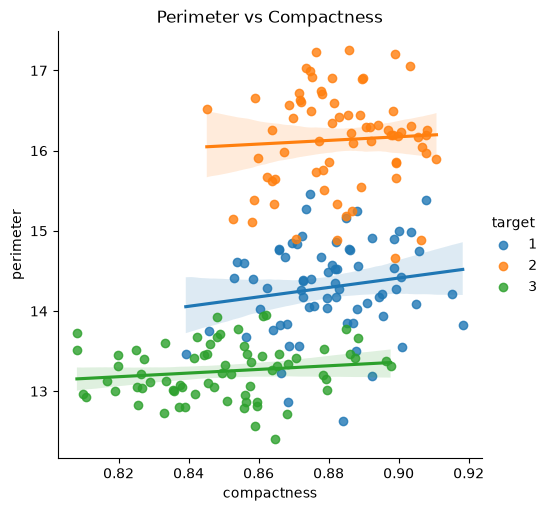

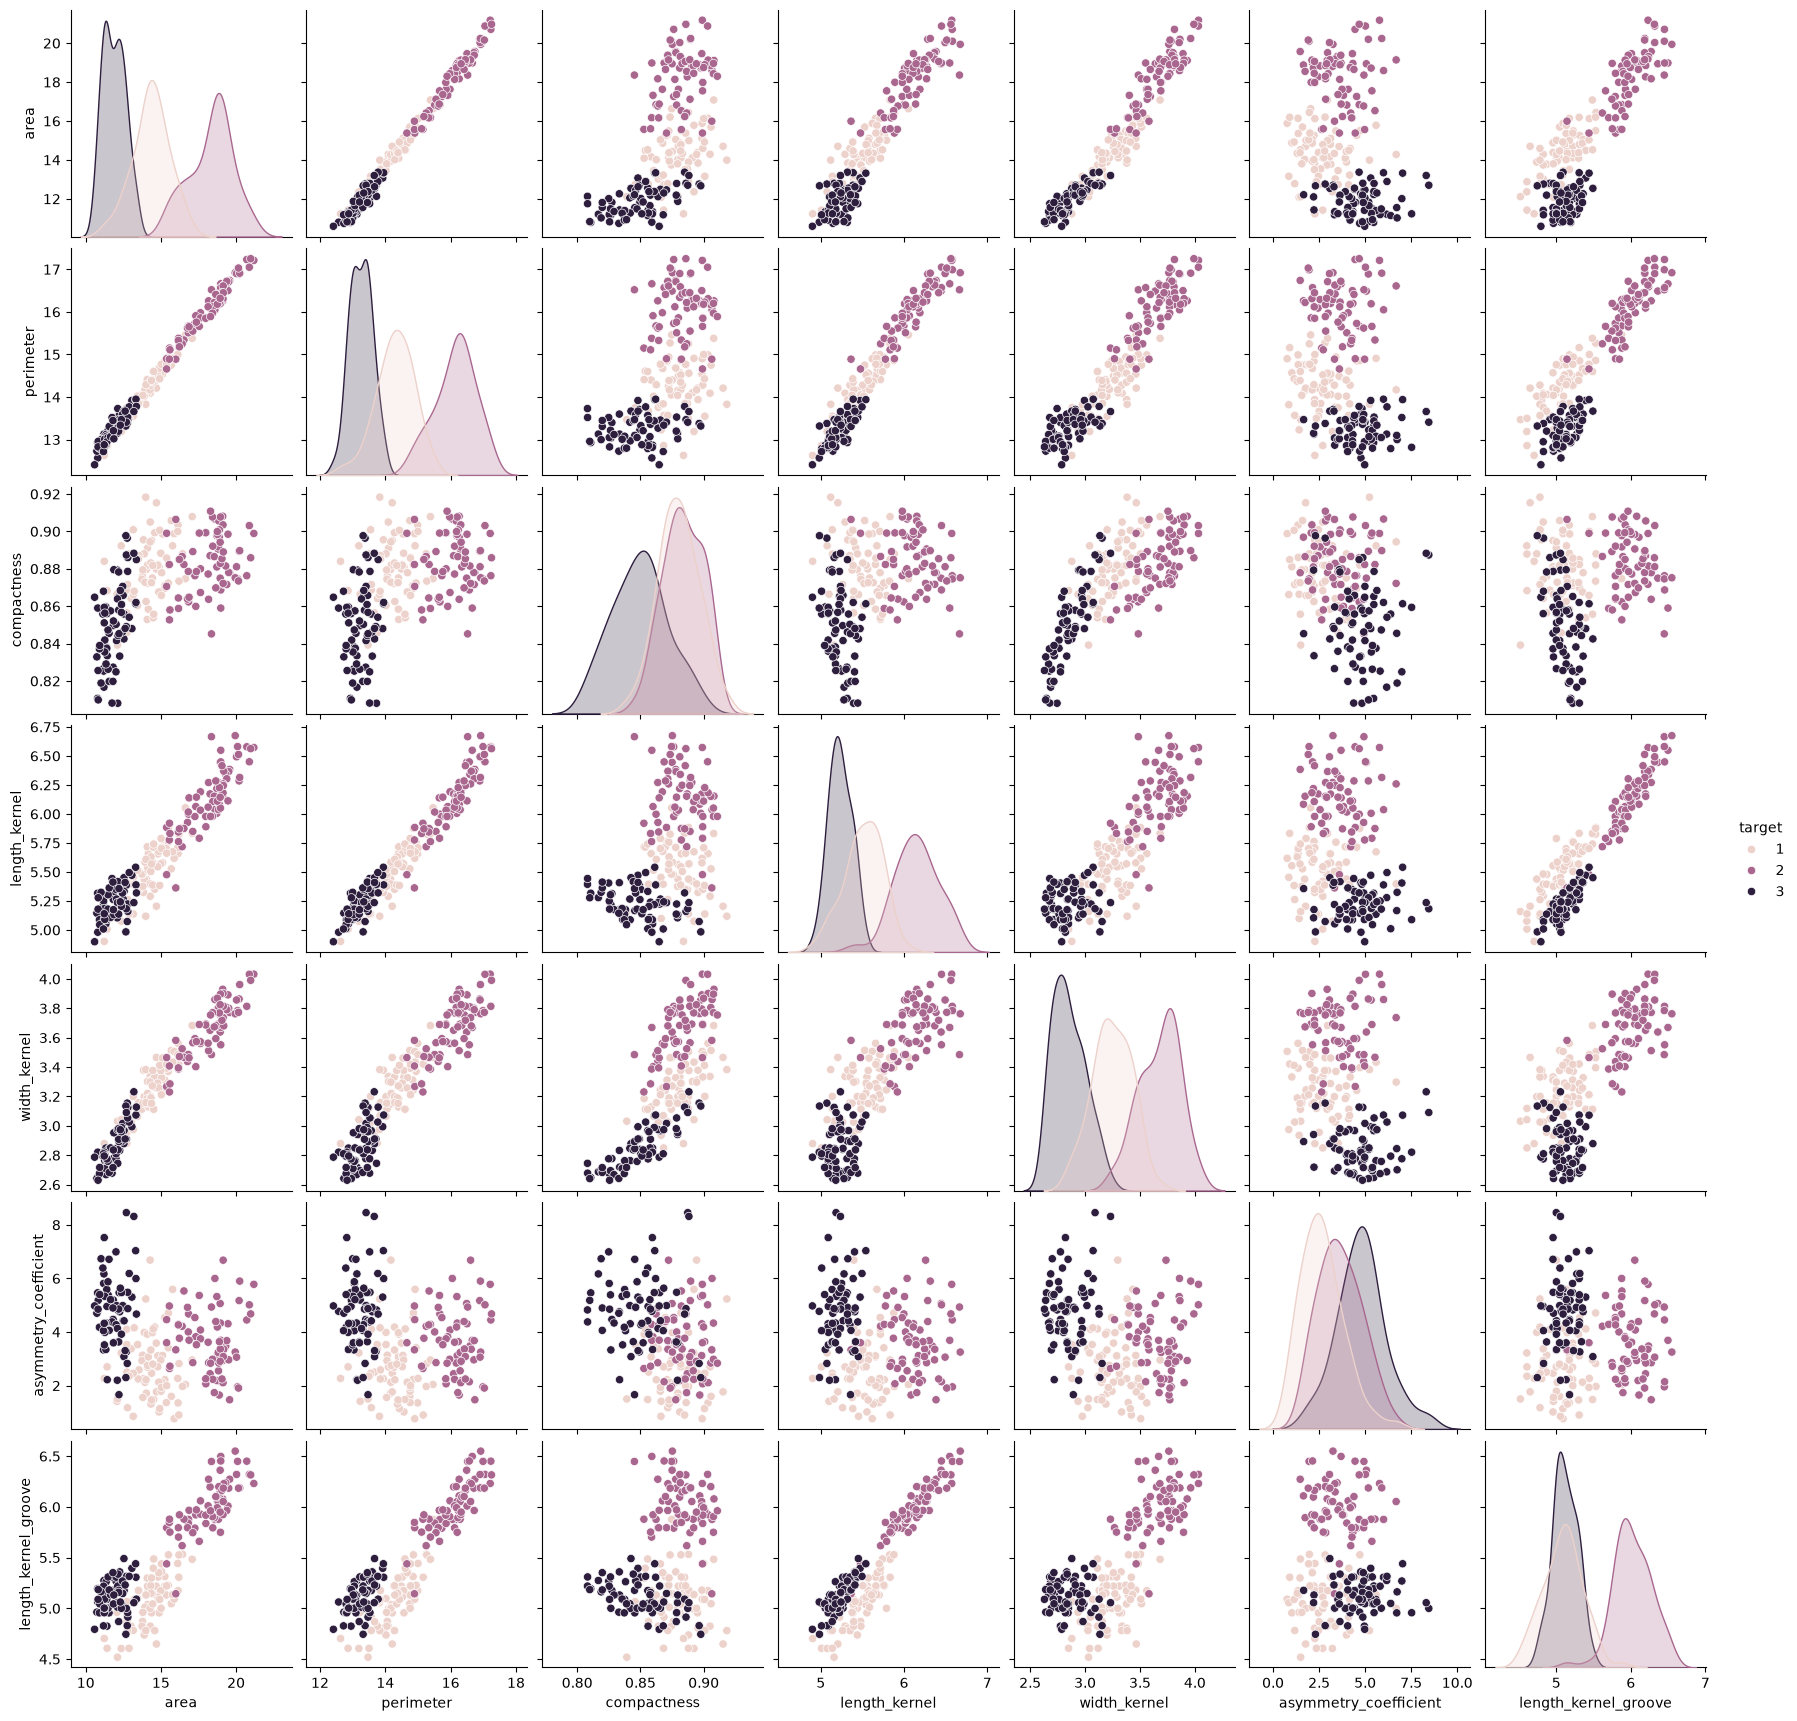

In [ ]:
# also try lmplot and pairplot
# lmplot: perimeter vs compactness
# Using lmplot we added a trend line to the scatter plot and with paiplot can shows every feature vs every other feature
sns.lmplot(x="compactness", y="perimeter", data=df, hue="target")
plt.title("Perimeter vs Compactness")
plt.show()

# pairplot: all variables
sns.pairplot(df, hue="target")
plt.show()
# The visualization result is very similar to assignment example


In [5]:
# determine the best number of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import homogeneity_score

x = df.drop("target", axis=1)
y = df["target"]
inertia = {}
homogeneity = {}

In [ ]:
# use kmeans to loop over candidate number of clusters 
# store inertia and homogeneity score in each iteration

# We try 1 to 9 clusters and measure two thing:
# 1) Inertia: How spread out the cluster are
# 2) Homogeneity: How pure each cluster is (higher = better)
# Finally, I looked for the elbow point where inertia stops dropping fast
for n_clusters in range(1, 10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=2020)
    kmeans.fit(x)
    
    inertia[n_clusters] = kmeans.inertia_
    
    if n_clusters > 1:
        homogeneity[n_clusters] = homogeneity_score(y, kmeans.labels_)
    else:
        homogeneity[n_clusters] = 0
# Elbow is at 3 as it is possible to see in the next visualization

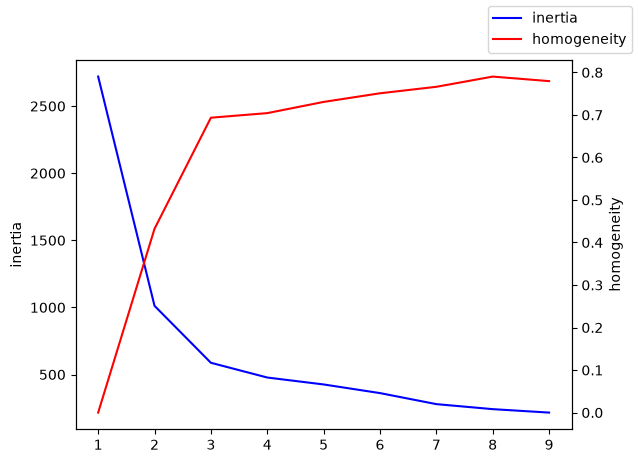

In [ ]:
# visualize inertia and homogeneity vs number of clusters
ax = sns.lineplot(
    x=list(inertia.keys()),
    y=list(inertia.values()),
    color="blue",
    label="inertia",
    legend=None,
)
ax.set_ylabel("inertia")
ax.twinx()
ax = sns.lineplot(
    x=list(homogeneity.keys()),
    y=list(homogeneity.values()),
    color="red",
    label="homogeneity",
    legend=None,
)
ax.set_ylabel("homogeneity")
ax.figure.legend()
plt.show()
# Finally, we achieve a similar visualization that the assignment example.
# Mission completed